In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
house = pd.read_csv(r'C:/Users/Hitesh/Desktop/College/TE/DSBDA/Practicals/Assignment-5/Banglore-Housing-Prices.csv')

In [3]:
house

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [4]:
house.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [5]:
house['size'] = house['size'].str.replace("\D","",regex = True)

In [6]:
house['size'] = house['size'].replace(np.NaN,house['size'].mode()[0])

In [7]:
house.isnull().sum()

location       1
size           0
total_sqft     0
bath          73
price          0
dtype: int64

In [8]:
house['bath'] = house['bath'].replace(np.NaN, house['bath'].mode()[0])

In [9]:
house.isnull().sum()

location      1
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [10]:
house = house.dropna()

In [11]:
house.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [12]:
house['total_sqft'] = house['total_sqft'].str.replace('\D',"",regex=True)

<ipython-input-12-3847c8857539>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house['total_sqft'] = house['total_sqft'].str.replace('\D',"",regex=True)


In [13]:
sqft = []
split_str = []

for i in house['total_sqft']:
    if '-' in i:
        split_str = i.split()
        average = (float(split_str[0]) + float(split_str[2]))/2
        sqft.append(float(average))
    else:
        sqft.append(float(i))

In [14]:
house['total_sqft'] = sqft

<ipython-input-14-460700dfd254>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house['total_sqft'] = sqft


In [15]:
price_per_sqft = []

for i,j in zip(house['price'],house['total_sqft']):
    price_per_sqft.append(i/j)

In [16]:
house['price_per_sqft'] = price_per_sqft

<ipython-input-16-11ba8fba07ef>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house['price_per_sqft'] = price_per_sqft


In [17]:
house.dtypes

location           object
size               object
total_sqft        float64
bath              float64
price             float64
price_per_sqft    float64
dtype: object

In [18]:
house['size'] = house['size'].apply(pd.to_numeric)

<ipython-input-18-289b131e9eba>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house['size'] = house['size'].apply(pd.to_numeric)


In [19]:
house.dtypes

location           object
size                int64
total_sqft        float64
bath              float64
price             float64
price_per_sqft    float64
dtype: object

C:\Users\Hitesh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='size'>

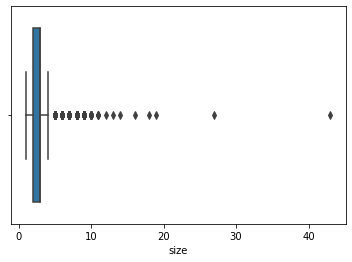

In [20]:
sns.boxplot(house['size'])

C:\Users\Hitesh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='price_per_sqft'>

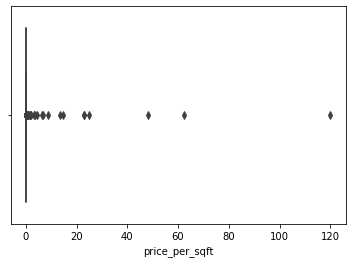

In [21]:
sns.boxplot(house['price_per_sqft'])

In [22]:
(house.describe())

,size,total_sqft,bath,price,price_per_sqft
count,13319.000000,1.331900e+04,13319.000000,13319.000000,1.331900e+04
mean,2.802763,5.886026e+07,2.688790,112.567621,9.356274e-02
std,1.294543,3.486988e+09,1.338801,148.977089,1.310280e+00
min,1.000000,1.000000e+00,1.000000,8.000000,4.716769e-10
25%,2.000000,1.100000e+03,2.000000,50.000000,4.190368e-02
50%,3.000000,1.286000e+03,2.000000,72.000000,5.381166e-02
75%,3.000000,1.703000e+03,3.000000,120.000000,7.272727e-02
max,43.000000,2.249814e+11,40.000000,3600.000000,1.200000e+02


In [48]:
house = house[(house['total_sqft']>=1100.0) & (house['total_sqft']<=1703.0)]

In [23]:
house = house[(house['size']>=2) & (house['size']<=3) & (house['price_per_sqft']>=0.042393) & (house['price_per_sqft']<=0.073171)]

C:\Users\Hitesh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='size'>

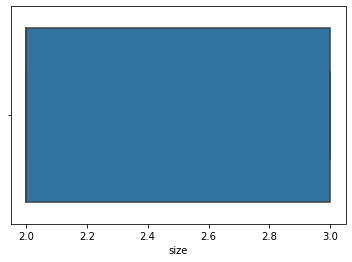

In [24]:
sns.boxplot(house['size'])

C:\Users\Hitesh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='price_per_sqft'>

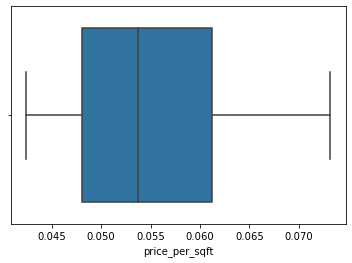

In [25]:
sns.boxplot(house['price_per_sqft'])

C:\Users\Hitesh\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='bath'>

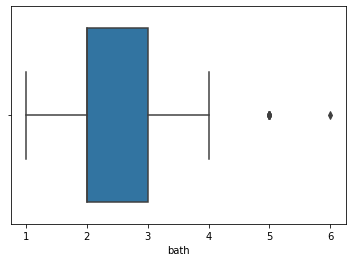

In [26]:
sns.boxplot(house['bath'])

In [27]:
house = house[(house['bath']>=2) & (house['bath']<=3)]

In [28]:
house.head()

,location,size,total_sqft,bath,price,price_per_sqft
2,Uttarahalli,3,1440.0,2.0,62.00,0.043056
3,Lingadheeranahalli,3,1521.0,3.0,95.00,0.062459
4,Kothanur,2,1200.0,2.0,51.00,0.042500
8,Marathahalli,3,1310.0,3.0,63.25,0.048282
14,Sarjapur,3,2250.0,3.0,148.00,0.065778


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [30]:
linear = LinearRegression()
scaler = StandardScaler()
encoder = LabelEncoder()

In [31]:
house['location'] = encoder.fit_transform(house['location'])

In [32]:
house['location']

2        672
3        433
4        412
8        460
14       588
        ... 
13302     58
13309    723
13310    548
13314    265
13317    552
Name: location, Length: 5531, dtype: int32

In [61]:
house_x = house.iloc[:,[0,1,2,3]]
house_y = house.iloc[:,4]

In [62]:
x_train,x_test,y_train,y_test = train_test_split(house_x,house_y, test_size=0.25,random_state=42)

In [63]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [64]:
linear.fit(x_train,y_train)

LinearRegression()

In [65]:
y_pred = linear.predict(x_test)

In [66]:
y_pred

array([93.84967723, 69.26463663, 58.59116279, 71.22518436, 71.18760645,
       60.42319875, 73.69384429, 83.31218029, 63.70276085, 58.52621003,
       64.79073023, 80.50359457, 62.65550147, 73.70254044, 75.17302111,
       66.18000121, 65.51859555, 75.60470711, 67.19177583, 70.87401626,
       60.91783896, 67.6913651 , 65.4250871 , 95.62196714, 68.27484601,
       61.49592903, 85.23168207, 67.99237777, 72.39191473, 91.96575481,
       89.77913991, 66.19220282, 61.36027789, 61.30035025, 87.36061788,
       73.0132523 , 64.19765106, 65.51699148, 69.6026697 , 75.16005931,
       74.89980651, 69.68569635, 96.57506339, 64.2247759 , 65.80678069,
       94.79738265, 96.22903613, 69.0913679 , 79.85227881, 63.77415102,
       67.36465009, 82.58333455, 58.76003995, 96.29054929, 63.61542961,
       60.31948468, 76.14363406, 65.14573239, 77.44141339, 88.06549993,
       64.53512663, 55.97201575, 69.61088544, 97.00553979, 85.3340024 ,
       69.68872291, 59.35706891, 64.13312152, 62.01801251, 77.03

In [67]:
mse = mean_squared_error(y_test,y_pred)

In [68]:
mse

126.05082396590781

In [69]:
r2 = r2_score(y_test,y_pred)

In [70]:
(1+r2)*0.5*100

74.70121502729134

In [71]:
mae = mean_absolute_error(y_test,y_pred)

In [72]:
mae

9.403309428009221

In [73]:
house_x

,location,size,total_sqft,bath
2,672,3,1440.0,2.0
3,433,3,1521.0,3.0
4,412,2,1200.0,2.0
8,460,3,1310.0,3.0
15,479,2,1175.0,2.0
...,...,...,...,...
13289,285,2,1349.0,2.0
13292,667,3,1440.0,2.0
13301,412,3,1454.0,3.0
13309,723,3,1675.0,3.0


In [74]:
r2

0.494024300545827